In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# project directory
abspath = os.path.abspath("")
project_dir = str(Path(abspath).parents[0])

# sub-directories
data_raw = os.path.join(project_dir, "data", "raw")
data_interim = os.path.join(project_dir, "data", "interim")
data_external = os.path.join(project_dir, "data", "external")
data_processed = os.path.join(project_dir, "data", "processed")

fpath_lfs = os.path.join(data_raw, "lfs", "eu")
main_data = r"Yearly Data\YearlyFiles_83_2019\_YearlyFiles"

In [3]:
# eu-lfs data
from src import utils

config = utils.load_config(os.path.join(project_dir, "configs", "main_config.yml"))

eulfs_raw = config["EU_LFS"]["FPATH_RAW_YF"]
eulfs_interim = config["EU_LFS"]["FPATH_INTERIM"]
eulfs_processed = config["EU_LFS"]["FPATH_PROCESSED"]

In [4]:
gdf = gpd.read_file(
    os.path.join(
        data_external,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)
nace_sections = pd.read_csv(
    os.path.join(data_external, "classifications", "nace_rev2_1d_section_codes.csv"),
    delimiter=";",
)

In [5]:
# cols_nace-granularity_isco-granularity
cols = [
    "WSTATOR",
    "SEX",
    "NACE1D",
    "ISCO3D",
    "COUNTRYW",
    "REGIONW",
    "FTPT",
    "REFYEAR",
    "COUNTRY",
    "REGION",
    "DEGURBA",
    "HHTYPE",
    "AGE",
    "ILOSTAT",
    "EDUC4WN",
    "HATLEV1D",
    "MAINSTAT",
    "INCDECIL",
    "COEFF",
]

# TODO: define NAN values globally or per column
na_values = [9, 99, 999, 9999]

# define dtypes of variables
dtypes = {
    "WSTATOR": "category",
    "SEX": "category",
    "NACE1D": "category",
    "ISCO3D": "category",
    "COUNTRYW": "category",
    "REGIONW": "category",
    "FTPT": "category",
    "REFYEAR": "int",
    "COUNTRY": "category",
    "REGION": "category",
    "DEGURBA": "category",
    "HHTYPE": "category",
    "AGE": "int",
    "ILOSTAT": "category",
    "EDUC4WN": "category",
    "HATLEV1D": "category",
    "MAINSTAT": "category",
    "INCDECIL": "float",
}

# countries to process
country = "DE"

# year to process
years = np.arange(2012, 2020, 1).astype(str)
years

array(['2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019'],
      dtype='<U11')

In [6]:
list_of_dfs = []
for year in years:

    # define fpath
    folder = "{}_YEAR_1998_onwards".format(country)
    file = "{}{}_y.csv".format(country, year)
    fpath_full = os.path.join(eulfs_raw, folder, file)

    # read raw data
    df = pd.read_csv(
        fpath_full,
        usecols=cols,
        na_values=na_values,
        dtype=dtypes,
        converters={"COEFF": lambda x: float(x) * 1000 if x != "" else np.nan},
    )

    # filter based on conditions
    cond_is_working = df.WSTATOR.isin(["1", "2"])  # beschäftigt
    cond_private_household = df.HHTYPE.isin(["1"])  # privater wohnraum
    cond_has_isco_code = df.ISCO3D.notna()
    cond_not_inactive = df.ILOSTAT.isin(["1", "2"])  # inaktiv
    cond_in_country = df.COUNTRYW.isin([country])  # pendler
    cond_valid_region = df.REGIONW != "00"
    cond_age = df.AGE <= 77  # (77 is the center of the 75-79 age band)
    cond_military = ~df.ISCO3D.isin(["011"])  # military

    df_sub = df.loc[
        cond_is_working
        & cond_private_household
        & cond_not_inactive
        & cond_in_country
        & cond_valid_region
        & cond_has_isco_code
        & cond_military
        & cond_age
    ]

    # remove categories that remain unused after filtering
    for col in df_sub.columns:
        if pd.api.types.is_categorical_dtype(df_sub[col]):
            df_sub.loc[:, col] = df_sub[col].cat.remove_unused_categories()

    # set NUTS code
    df_sub["NUTS_ID"] = df_sub["COUNTRYW"].astype(str) + df_sub["REGIONW"].astype(str)

    # append clean df
    list_of_dfs.append(df_sub)

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15820\529094595.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub.loc[:, col] = df_sub[col].cat.remove_unused_categories()
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15820\529094595.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub["NUTS_ID"] = df_sub["COUNTRYW"].astype(str) + df_sub["REGIONW"].astype(str)
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15820\529094595.py:33: SettingWithCopyWarning: 
A value is trying to be set o

In [7]:
df_merged = pd.concat(list_of_dfs, axis=0).reset_index(drop=True)
df_merged = df_merged.astype(dtypes)

In [8]:
df_isco = pd.read_csv(
    os.path.join(data_raw, "esco", "v1.1.0", "ISCOGroups_en.csv"),
    usecols=["code", "preferredLabel"],
)

df_isco = df_isco.loc[df_isco.code.astype(str).str.len() < 4].reset_index(drop=True)
df_isco.code = df_isco.code.astype(str)
df_isco.code = df_isco.code.str.pad(width=3, side="left", fillchar="0")
df_isco = df_isco.rename(columns={"preferredLabel": "ISCO3D_label"})

In [9]:
df_gbn = pd.read_csv(
    os.path.join(data_interim, "ESCO_ONET_METADATA_gbn.csv"),
    index_col=0,
    usecols=["preferred_label", "isco_level_3", "is_brown", "is_green", "is_neutral"],
)

df_gbn = df_gbn.rename(columns={"isco_level_3": "ISCO3D"})

df_gbn["type"] = df_gbn[["is_brown", "is_green", "is_neutral"]].idxmax(axis=1)
df_gbn = df_gbn[["ISCO3D", "type"]]

gbn_by_isco3 = (
    df_gbn.groupby("ISCO3D").type.value_counts().to_frame("count").unstack().fillna(0)
)
gbn_by_isco3.columns = gbn_by_isco3.columns.droplevel()
gbn_by_isco3_shares = gbn_by_isco3.apply(lambda x: x / gbn_by_isco3.sum(axis=1), axis=0)
gbn_by_isco3_shares = gbn_by_isco3_shares.reset_index()
gbn_by_isco3_shares.ISCO3D = gbn_by_isco3_shares.ISCO3D.astype(str)

In [10]:
gbn_by_isco3_shares_merged = pd.merge(
    gbn_by_isco3_shares, df_isco, left_on="ISCO3D", right_on="code", how="left"
)
gbn_by_isco3_shares_merged = gbn_by_isco3_shares_merged.drop("code", axis=1)

gbn_by_isco3_shares_merged.sort_values("is_brown", ascending=False).head(10)

,ISCO3D,is_brown,is_green,is_neutral,ISCO3D_label
103,817,1.000000,0.000000,0.000000,Wood processing and papermaking plant operators
102,816,0.981818,0.000000,0.018182,Food and related products machine operators
94,752,0.933333,0.000000,0.066667,"Wood treaters, cabinet-makers and related trad..."
98,812,0.894737,0.052632,0.052632,Metal processing and finishing plant operators
99,813,0.870968,0.000000,0.129032,Chemical and photographic products plant and m...
100,814,0.852941,0.000000,0.147059,"Rubber, plastic and paper products machine ope..."
97,811,0.846154,0.000000,0.153846,Mining and mineral processing plant operators
104,818,0.833333,0.000000,0.166667,Other stationary plant and machine operators
38,312,0.508197,0.000000,0.491803,"Mining, manufacturing and construction supervi..."
101,815,0.411765,0.000000,0.588235,"Textile, fur and leather products machine oper..."


In [11]:
df_merged_all_vars = pd.merge(
    df_merged, gbn_by_isco3_shares_merged, on="ISCO3D", how="left"
)

In [12]:
df_merged_all_vars = pd.merge(
    df_merged_all_vars, nace_sections, on="NACE1D", how="left"
)

In [13]:
earnings_deciles_de = pd.read_csv(
    os.path.join(data_raw, "metadata", "earnings_distribution_de_2016.csv"),
    delimiter=";",
).astype(float)

df_merged_all_vars = pd.merge(
    df_merged_all_vars,
    earnings_deciles_de,
    left_on="INCDECIL",
    right_on="decil",
    how="left",
)

In [14]:
cond_isco = df_merged_all_vars.ISCO3D_label.str.contains(
    "mining|mine|miner", case=False, regex=True
)
cond_nace = df_merged_all_vars.NACE1D.isin(["B", "D"])
df_merged_all_vars["mining"] = cond_isco & cond_nace

In [15]:
df_merged_all_vars["is_brown_abs"] = (
    df_merged_all_vars.is_brown * df_merged_all_vars.COEFF
)
df_merged_all_vars["is_neutral_abs"] = (
    df_merged_all_vars.is_neutral * df_merged_all_vars.COEFF
)
df_merged_all_vars["is_green_abs"] = (
    df_merged_all_vars.is_green * df_merged_all_vars.COEFF
)

In [16]:
df_merged_all_vars.to_csv(os.path.join(eulfs_interim, "eu_lfs_merged_allyears_de.csv"))

In [17]:
df_mining = df_merged_all_vars[df_merged_all_vars.mining]

Samples and employment per sector over time

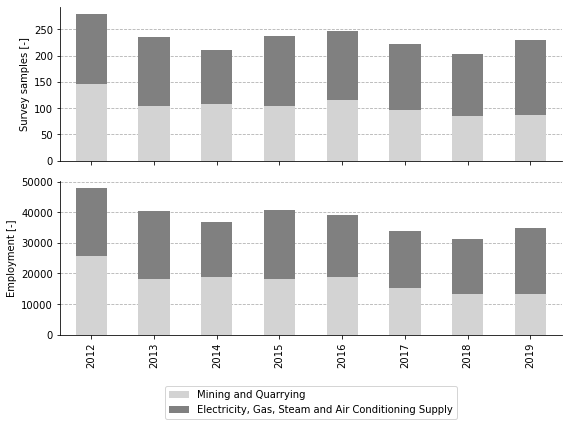

In [18]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))

df_mining.groupby(["REFYEAR", "NACE1D_label"]).count().SEX.unstack().iloc[
    :, ::-1
].plot.bar(stacked=True, color=["lightgrey", "grey"], ax=axes[0], legend=False)
axes[0].set_ylabel("Survey samples [-]")
axes[0].set_xlabel(None)

df_mining.groupby(["REFYEAR", "NACE1D_label"]).COEFF.sum().unstack().iloc[
    :, ::-1
].plot.bar(stacked=True, ax=axes[1], color=["lightgrey", "grey"])
axes[1].set_ylabel("Employment [-]")
axes[1].set_xlabel(None)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.3))

axes[0].set_axisbelow(True)
axes[0].grid(axis="y", linestyle="--", zorder=0)
axes[1].set_axisbelow(True)
axes[1].grid(axis="y", linestyle="--", zorder=0)

sns.despine()
plt.tight_layout()

In [19]:
df_mining.groupby(["REFYEAR"]).count()

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,COUNTRY,REGION,DEGURBA,...,is_green,is_neutral,ISCO3D_label,NACE1D_label,decil,annual_earnings_2016,mining,is_brown_abs,is_neutral_abs,is_green_abs
REFYEAR,,,,,,,,,,,,,,,,,,,,,
2012,279,279,279,279,279,279,279,279,279,279,...,279,279,279,279,203,203,279,279,279,279
2013,235,235,235,235,235,235,235,235,235,235,...,235,235,235,235,182,182,235,235,235,235
2014,211,211,211,211,211,211,211,211,211,211,...,211,211,211,211,148,148,211,211,211,211
2015,237,237,237,237,237,237,237,237,237,237,...,237,237,237,237,177,177,237,237,237,237
2016,246,246,246,246,246,246,246,246,246,246,...,246,246,246,246,183,183,246,246,246,246
2017,221,221,221,221,221,221,221,221,221,221,...,221,221,221,221,162,162,221,221,221,221
2018,203,203,203,203,203,203,203,203,203,203,...,203,203,203,203,145,145,203,203,203,203
2019,229,229,229,229,229,229,229,229,229,229,...,229,229,229,229,164,164,229,229,229,229


In [20]:
df_mining.groupby(["REFYEAR", "NACE1D_label"]).COEFF.sum()

REFYEAR  NACE1D_label                                       
2012     Electricity, Gas, Steam and Air Conditioning Supply    22386.2525
         Mining and Quarrying                                   25555.2500
2013     Electricity, Gas, Steam and Air Conditioning Supply    22182.3300
         Mining and Quarrying                                   18260.7250
2014     Electricity, Gas, Steam and Air Conditioning Supply    17914.0775
         Mining and Quarrying                                   18905.0275
2015     Electricity, Gas, Steam and Air Conditioning Supply    22711.8625
         Mining and Quarrying                                   18100.6825
2016     Electricity, Gas, Steam and Air Conditioning Supply    20460.9100
         Mining and Quarrying                                   18752.1925
2017     Electricity, Gas, Steam and Air Conditioning Supply    18593.1100
         Mining and Quarrying                                   15241.5950
2018     Electricity, Gas, Steam and Ai